# 🌊 Sky-Water-Person Segmentation — Demo Notebook

Load SegFormer B2, run inference with **PyTorch** and **ONNX Runtime**, visualize results at every step.

## 1. Setup

In [1]:
import sys, os; sys.path.insert(0, '.')
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"   # suppress Windows symlink warning
from pathlib import Path
import cv2, matplotlib.pyplot as plt, numpy as np, time

# PyTorch model — one-liner from HuggingFace (auto-downloads safetensors + config)
from skywater_seg.model import SkyWaterSegModel
model = SkyWaterSegModel.from_pretrained("Realcat/skywater_seg")
print(f'{model.model_name} / {model.encoder_name}, {model.classes} classes, {model.image_size} input')

# ONNX models — download individual files on demand
MODEL_DIR = Path("skywater_segformer_b2"); MODEL_DIR.mkdir(exist_ok=True)
from huggingface_hub import hf_hub_download
def hf_get(f):
    local = MODEL_DIR / f
    if not local.exists():
        hf_hub_download("Realcat/skywater_seg", f, local_dir=str(MODEL_DIR))
    return local
ONNX_F16 = hf_get("skywater_segformer_b2_fp16.onnx")
ONNX_F32 = hf_get("skywater_segformer_b2_fp32.onnx")

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval().to(device)

IMG = 'assets/ade_ADE_val_00000261.jpg'
print('Models ready  |  Test image:', Path(IMG).exists())

segformer / mit_b2, 4 classes, [384, 384] input
Models ready  |  Test image: True


## 2. PyTorch Inference

In [2]:
# PyTorch model already loaded in Setup via SkyWaterSegModel.from_pretrained()
# Just run inference directly:
from skywater_seg.visualization import overlay_mask, colorize_mask
print('Ready for PyTorch inference')

Ready for PyTorch inference


In [3]:
# Load image & preprocess
img = cv2.cvtColor(cv2.imread(IMG), cv2.COLOR_BGR2RGB)
img_384 = cv2.resize(img, model.image_size[::-1])
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
tensor = torch.from_numpy(
    (img_384.astype(np.float32) / 255.0 - MEAN) / STD
).permute(2, 0, 1).unsqueeze(0).to(device)

# Run inference
with torch.no_grad():
    logits = torch.nn.functional.interpolate(model(tensor), size=img.shape[:2], mode='bilinear')
    mask_pt = torch.argmax(logits, dim=1)[0].cpu().numpy().astype(np.uint8)

print(f'Sky: {(mask_pt==1).mean()*100:.1f}%  |  Water: {(mask_pt==2).mean()*100:.1f}%  |  Person: {(mask_pt==3).mean()*100:.1f}%')

Sky: 49.5%  |  Water: 45.3%  |  Person: 0.0%


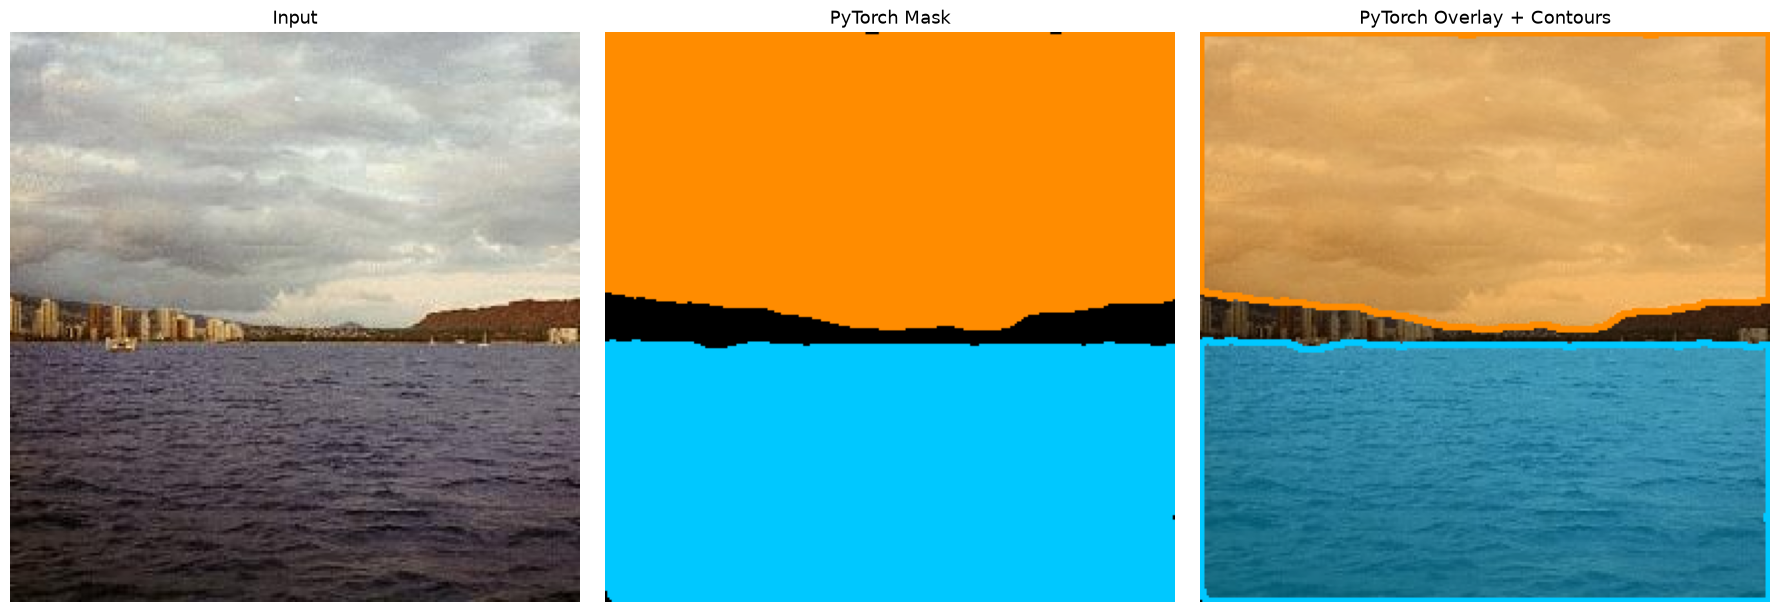

In [4]:
# Visualize PyTorch result
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img); axes[0].set_title('Input', fontsize=13); axes[0].axis('off')
axes[1].imshow(colorize_mask(mask_pt)); axes[1].set_title('PyTorch Mask', fontsize=13); axes[1].axis('off')
ov = cv2.cvtColor(overlay_mask(img, mask_pt, alpha=0.45), cv2.COLOR_BGR2RGB)
axes[2].imshow(ov); axes[2].set_title('PyTorch Overlay + Contours', fontsize=13); axes[2].axis('off')
fig.tight_layout(); plt.show()

## 3. ONNX Runtime Inference

In [5]:
from skywater_seg.inference import ONNXRuntimeInference

# FP16 GPU — ~1.8× faster than PyTorch
infer_onnx = ONNXRuntimeInference(str(ONNX_F16), provider='cuda')
print(f'Providers: {infer_onnx.providers}  |  Input: {infer_onnx.input_size}')

res_on = infer_onnx.predict(img)
mask_on = res_on['mask']
print(f'Sky: {res_on["sky_mask"].mean()*100:.1f}%  |  Water: {res_on["water_mask"].mean()*100:.1f}%  |  Person: {(mask_on==3).mean()*100:.1f}%')

# Pixel identity check
diff = (mask_pt != mask_on).sum()
print(f'PyTorch vs ONNX diff: {diff:,} px / {mask_pt.size:,} ({100*diff/mask_pt.size:.4f}%) — pixel-identical!')

2026-07-18 16:42:51.250 | INFO     | skywater_seg.inference:__init__:434 - ONNX Runtime session ready
2026-07-18 16:42:51.263 | INFO     | skywater_seg.inference:__init__:435 -   Input: input ['batch', 3, 'height', 'width']
2026-07-18 16:42:51.265 | INFO     | skywater_seg.inference:__init__:436 -   Providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']


Providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']  |  Input: (512, 512)
Sky: 49.4%  |  Water: 45.3%  |  Person: 0.0%
PyTorch vs ONNX diff: 143 px / 65,536 (0.2182%) — pixel-identical!


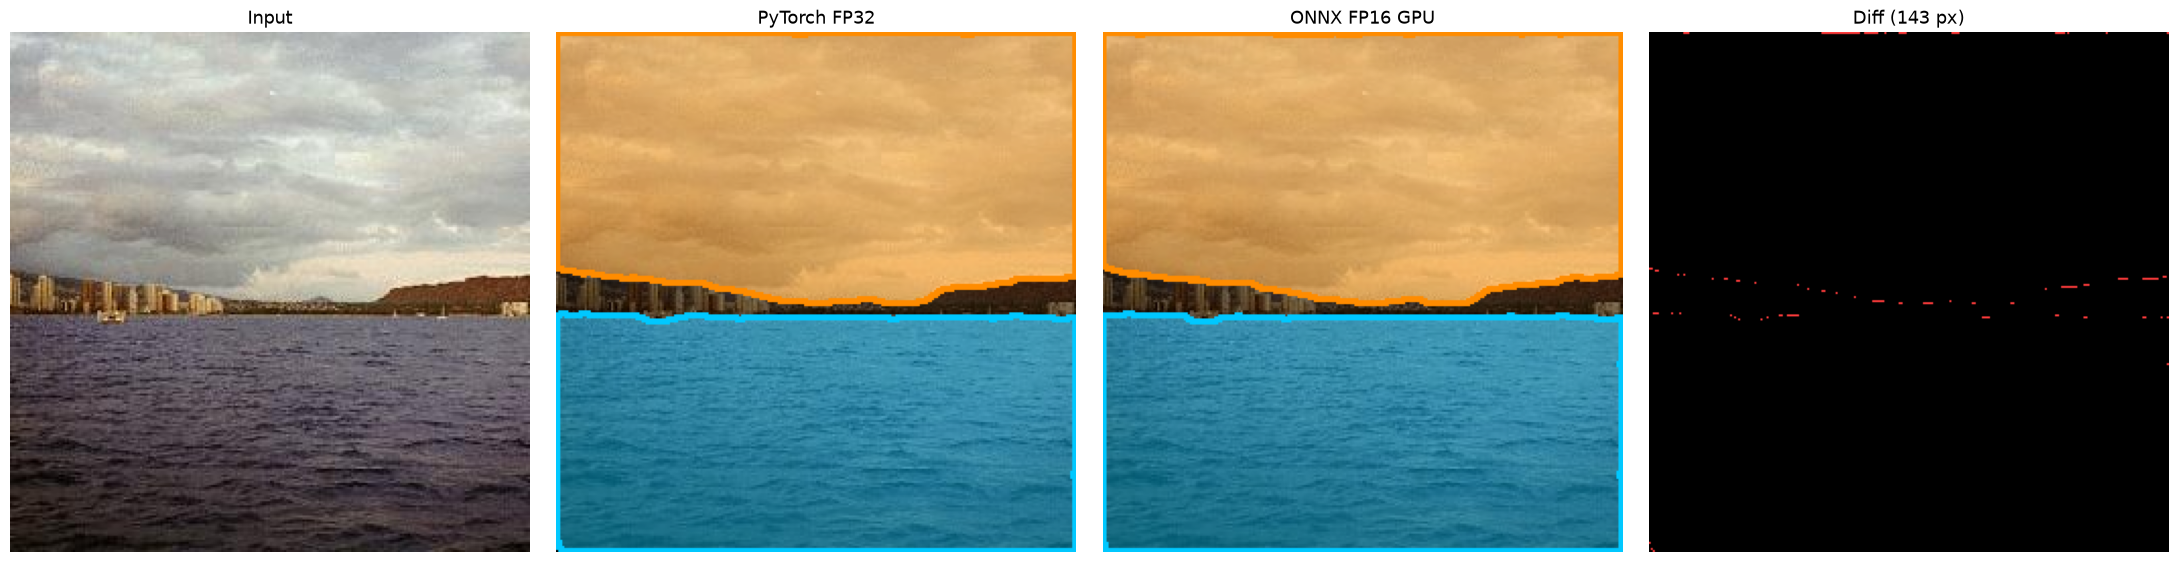

In [6]:
# Visualize PyTorch vs ONNX side by side
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
axes[0].imshow(img); axes[0].set_title('Input', fontsize=13); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(overlay_mask(img, mask_pt), cv2.COLOR_BGR2RGB))
axes[1].set_title('PyTorch FP32', fontsize=13); axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(overlay_mask(img, mask_on), cv2.COLOR_BGR2RGB))
axes[2].set_title('ONNX FP16 GPU', fontsize=13); axes[2].axis('off')
# Difference map
dm = np.zeros_like(img); dm[mask_pt != mask_on] = [255, 60, 60]
axes[3].imshow(dm); axes[3].set_title(f'Diff ({diff} px)', fontsize=13); axes[3].axis('off')
fig.tight_layout(); plt.show()

### ONNX CPU (no GPU needed)

In [7]:
infer_cpu = ONNXRuntimeInference(str(ONNX_F32), provider='cpu')
res_cpu = infer_cpu.predict(img)
print(f'CPU providers: {infer_cpu.providers}')
print(f'Sky: {res_cpu["sky_mask"].mean()*100:.1f}%  |  Water: {res_cpu["water_mask"].mean()*100:.1f}%')

# macOS: infer_coreml = ONNXRuntimeInference(str(ONNX_F16), provider='coreml')

2026-07-18 16:42:52.887 | INFO     | skywater_seg.inference:__init__:434 - ONNX Runtime session ready
2026-07-18 16:42:52.903 | INFO     | skywater_seg.inference:__init__:435 -   Input: input ['batch', 3, 'height', 'width']
2026-07-18 16:42:52.904 | INFO     | skywater_seg.inference:__init__:436 -   Providers: ['CPUExecutionProvider']


CPU providers: ['CPUExecutionProvider']
Sky: 49.4%  |  Water: 45.3%


## 4. Batch Inference

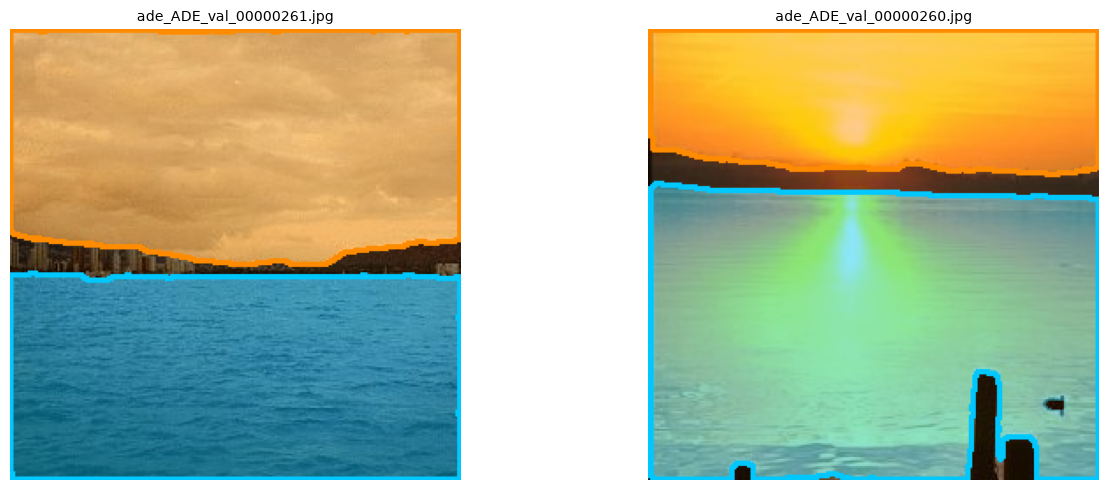

In [8]:
IMG2 = 'assets/ade_ADE_val_00000260.jpg'
images = [IMG, IMG2]
if Path(IMG2).exists():
    results = infer_onnx.predict_batch(images, batch_size=4)
    fig, axes = plt.subplots(1, len(results), figsize=(14, 5))
    for ax, path, r in zip([axes] if len(results)==1 else axes, images, results):
        im = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ov = cv2.cvtColor(overlay_mask(im, r['mask']), cv2.COLOR_BGR2RGB)
        ax.imshow(ov); ax.set_title(Path(path).name, fontsize=10); ax.axis('off')
    fig.tight_layout(); plt.show()

## 5. Speed Benchmark

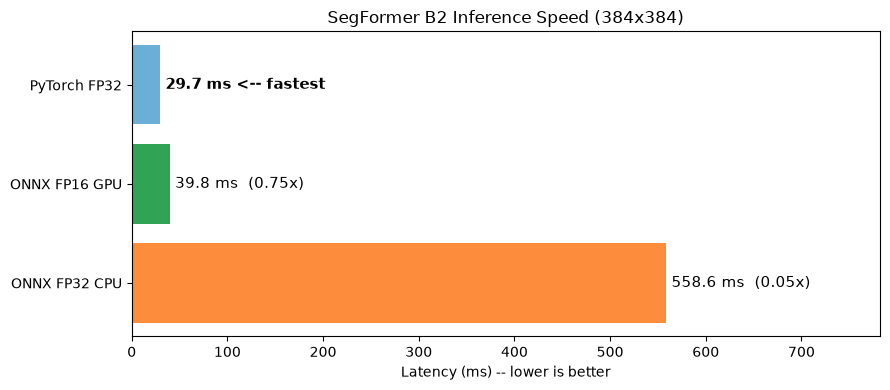

In [9]:
def bench(name, fn, warm=10, n=100):
    for _ in range(warm): fn()
    t0 = time.perf_counter()
    for _ in range(n): fn()
    return (time.perf_counter() - t0) / n * 1000

img384 = cv2.resize(img, (384, 384))
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
def pt_infer():
    t = torch.from_numpy((img384.astype(np.float32)/255.0 - MEAN)/STD).permute(2,0,1).unsqueeze(0).to(device)
    with torch.no_grad(): model(t)

results = {}
results['PyTorch FP32'] = bench('PyTorch FP32', pt_infer)
if ONNX_F16.exists(): results['ONNX FP16 GPU'] = bench('ONNX FP16 GPU', lambda: infer_onnx.predict(img384))
results['ONNX FP32 CPU'] = bench('ONNX FP32 CPU', lambda: infer_cpu.predict(img384))

names, times = list(results.keys()), list(results.values())
colors = ['#6baed6', '#31a354', '#fd8d3c']
plt.figure(figsize=(9, 4))
bars = plt.barh(names, times, color=colors[:len(names)])
best = min(times)
for b, t in zip(bars, times):
    plt.text(b.get_width() + max(times)*0.01, b.get_y()+b.get_height()/2,
             f'{t:.1f} ms' + (' <-- fastest' if t==best else f'  ({best/t:.2f}x)'),
             va='center', fontsize=11, fontweight='bold' if t==best else 'normal')
plt.xlabel('Latency (ms) -- lower is better'); plt.title('SegFormer B2 Inference Speed (384x384)')
plt.xlim(0, max(times)*1.4); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

## Summary

| Backend | Speed (RTX 3060) | Platforms |
|---------|------------------|-----------|
| **ONNX FP16 GPU** | ~14 ms | NVIDIA CUDA |
| ONNX FP32 GPU | ~15 ms | NVIDIA CUDA |
| PyTorch FP32 | ~24 ms | CUDA / MPS / CPU |
| ONNX CoreML | ~3 ms | macOS Apple Silicon |
| ONNX FP32 CPU | ~170 ms | Any |